In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Airbnb_Open_Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "arianazmoudeh/airbnbopendata",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_12629/2284741635.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|████████████████████████████████████████████████████████████████████| 10.5M/10.5M [00:01<00:00, 7.02MB/s]

Extracting zip of Airbnb_Open_Data.csv...


First 5 records:         id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73

/home/umar/miniforge3/envs/ml/lib/python3.11/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [5]:
df.columns.tolist()

['id',
 'NAME',
 'host id',
 'host_identity_verified',
 'host name',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country code',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'last review',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'house_rules',
 'license']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  str    
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  str    
 4   host name                       102193 non-null  str    
 5   neighbourhood group             102570 non-null  str    
 6   neighbourhood                   102583 non-null  str    
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  str    
 10  country code                    102468 non-null  str    
 11  instant_bookable                102494 non-null  object 
 12  cancellation_policy        

In [8]:
df.shape

(102599, 26)

In [9]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [10]:
df['last review']

0         10/19/2021
1          5/21/2022
2                NaN
3           7/5/2019
4         11/19/2018
             ...    
102594           NaN
102595      7/6/2015
102596           NaN
102597    10/11/2015
102598           NaN
Name: last review, Length: 102599, dtype: str

In [11]:
cols_to_drop = ['id', 'NAME', 'host id', 'country', 'country code', 'house_rules', 'license', 'last review']
df.drop(columns=cols_to_drop, inplace=True)

In [13]:
df

,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,$966,$193,10.0,9.0,0.21,4.0,6.0,286.0
1,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,0.38,4.0,2.0,228.0
2,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,5.0,1.0,352.0
3,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,4.64,4.0,1.0,322.0
4,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,0.10,3.0,1.0,289.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,False,flexible,Private room,2003.0,$844,$169,1.0,0.0,NaN,3.0,1.0,227.0
102595,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,True,moderate,Private room,2016.0,$837,$167,1.0,1.0,0.02,2.0,2.0,395.0
102596,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,True,moderate,Private room,2009.0,$988,$198,3.0,0.0,NaN,5.0,1.0,342.0
102597,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,True,strict,Entire home/apt,2015.0,$546,$109,2.0,5.0,0.10,3.0,1.0,386.0


In [14]:
df['price'] = df['price'].str.replace('[$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].str.replace('[$,]', '', regex=True).astype(float)

In [15]:
df[['price', 'service fee']].describe()

,price,service fee
count,102352.000000,102326.000000
mean,625.293536,125.026924
std,331.671614,66.325739
min,50.000000,10.000000
25%,340.000000,68.000000
50%,624.000000,125.000000
75%,913.000000,183.000000
max,1200.000000,240.000000


In [16]:
df['price'].value_counts().sort_index().head(20)

price
50.0     94
51.0     86
52.0     87
53.0     65
54.0     67
55.0     99
56.0    107
57.0     87
58.0     81
59.0    110
60.0     82
61.0     79
62.0     80
63.0     90
64.0     96
65.0     81
66.0     73
67.0     90
68.0    100
69.0     94
Name: count, dtype: int64

In [20]:
df.fillna({'reviews per month': 0}, inplace=True)

,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
0,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,966.0,193.0,10.0,9.0,0.21,4.0,6.0,286.0
1,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,142.0,28.0,30.0,45.0,0.38,4.0,2.0,228.0
2,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,620.0,124.0,3.0,0.0,0.00,5.0,1.0,352.0
3,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,True,moderate,Entire home/apt,2005.0,368.0,74.0,30.0,270.0,4.64,4.0,1.0,322.0
4,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,False,moderate,Entire home/apt,2009.0,204.0,41.0,10.0,9.0,0.10,3.0,1.0,289.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,False,flexible,Private room,2003.0,844.0,169.0,1.0,0.0,0.00,3.0,1.0,227.0
102595,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,True,moderate,Private room,2016.0,837.0,167.0,1.0,1.0,0.02,2.0,2.0,395.0
102596,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,True,moderate,Private room,2009.0,988.0,198.0,3.0,0.0,0.00,5.0,1.0,342.0
102597,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,True,strict,Entire home/apt,2015.0,546.0,109.0,2.0,5.0,0.10,3.0,1.0,386.0


In [22]:
df['reviews per month'].isna().sum()

np.int64(0)

In [23]:
df.dropna(subset=['price'], inplace=True)

In [24]:
df.isnull().sum()

host_identity_verified            285
host name                         401
neighbourhood group                28
neighbourhood                      15
lat                                 8
long                                8
instant_bookable                  100
cancellation_policy                71
room type                           0
Construction year                 210
price                               0
service fee                       239
minimum nights                    409
number of reviews                 183
reviews per month                   0
review rate number                326
calculated host listings count    319
availability 365                  448
dtype: int64

In [27]:
df.drop('host name', axis=1, inplace=True)

In [28]:
df.shape

(102352, 17)

In [29]:
df.dropna(inplace=True)

In [30]:
df.shape

(100097, 17)

In [31]:
df.isnull().sum()

host_identity_verified            0
neighbourhood group               0
neighbourhood                     0
lat                               0
long                              0
instant_bookable                  0
cancellation_policy               0
room type                         0
Construction year                 0
price                             0
service fee                       0
minimum nights                    0
number of reviews                 0
reviews per month                 0
review rate number                0
calculated host listings count    0
availability 365                  0
dtype: int64

In [33]:
df['neighbourhood'].nunique()

224

In [36]:
neighbourhood_means = df.groupby('neighbourhood')['price'].mean()
df['neighbourhood_encoded'] = df['neighbourhood'].map(neighbourhood_means)
df.drop(columns=['neighbourhood'], inplace=True)

In [37]:
df['neighbourhood_encoded'].describe()

count    100097.000000
mean        625.365685
std          20.490232
min         107.666667
25%         617.693953
50%         624.189369
75%         632.300164
max        1045.000000
Name: neighbourhood_encoded, dtype: float64

In [39]:
import pandas as pd

In [42]:
df = pd.get_dummies(df, columns=['neighbourhood group', 'room type',
                                'cancellation_policy', 'instant_bookable',
                                'host_identity_verified'], drop_first=True)

In [43]:
df.shape

(100097, 24)

In [44]:
df.head()

,lat,long,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,...,neighbourhood group_Queens,neighbourhood group_Staten Island,neighbourhood group_brookln,room type_Hotel room,room type_Private room,room type_Shared room,cancellation_policy_moderate,cancellation_policy_strict,instant_bookable_True,host_identity_verified_verified
0,40.64749,-73.97237,2020.0,966.0,193.0,10.0,9.0,0.21,4.0,6.0,...,False,False,False,False,True,False,False,True,False,False
1,40.75362,-73.98377,2007.0,142.0,28.0,30.0,45.0,0.38,4.0,2.0,...,False,False,False,False,False,False,True,False,False,True
3,40.68514,-73.95976,2005.0,368.0,74.0,30.0,270.0,4.64,4.0,1.0,...,False,False,False,False,False,False,True,False,True,False
4,40.79851,-73.94399,2009.0,204.0,41.0,10.0,9.0,0.10,3.0,1.0,...,False,False,False,False,False,False,True,False,False,True
5,40.74767,-73.97500,2013.0,577.0,115.0,3.0,74.0,0.59,3.0,1.0,...,False,False,False,False,False,False,False,False,True,True


In [51]:
X = df.drop(columns=['price', 'service fee'])
y = df['price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"R^2: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

R^2: 0.003
MAE: 285.97


In [53]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"R^2: {r2_score(y_test, y_pred_rf):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")

R^2: 0.331
MAE: 217.20


In [55]:
import matplotlib.pyplot as plt

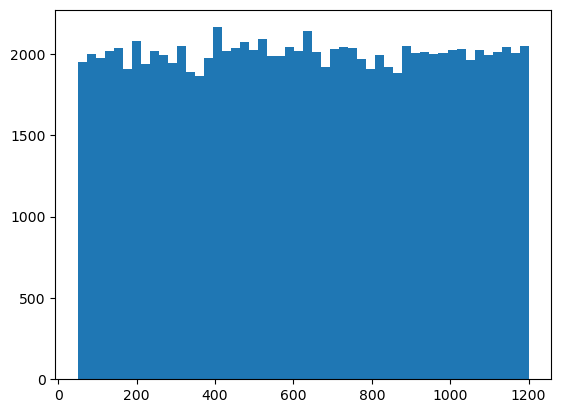

In [56]:
plt.hist(y, bins=50)
plt.show()

In [57]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f"R^2: {r2_score(y_test, y_pred_xgb):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")

R^2: 0.007
MAE: 285.27
